# Getting the data

In [1]:
!pip install yfinance --quiet

In [2]:
!pip install vaderSentiment --quiet

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import yfinance as y

timeline = pd.read_csv("/Users/minamohebbi/Downloads/timeline.csv")
timeline['Date'] = pd.to_datetime(timeline['Date'], errors='coerce')
timeline.head()

,Date,Country,Category,Description,Links,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,2025-05-12,China,"Trade Deficits, Retaliation",The United States and China reach an agreement...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-05-02,"China, Hong Kong","Trade Deficits, Retaliation",The U.S. ends ends de minimis treatment for lo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-29,World,"Aluminum, Autos, Steel, Fentanyl and Immigration",Addressing certain tariffs on imported article...,AMENDMENTS TO ADJUSTING IMPORTS OF AUTOMOBILES...,ADDRESSING CERTAIN TARIFFS ON IMPORTED ARTICLES,AMENDMENTS TO ADJUSTING IMPORTS OF AUTOMOBILES...,NaN,NaN,NaN,NaN
3,2025-04-24,World,Critical minerals,Unleashing America’s offshore critical mineral...,UNLEASHING AMERICA’S OFFSHORE CRITICAL MINERAL...,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-23,World,Trucks,Truck imports as a national security threat: T...,Notice of Request for Public Comments on Secti...,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
timeline = timeline.drop(columns=['Links', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'])

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import yfinance as yf

In [6]:
#compute vader sentiment for each event

analyzer = SentimentIntensityAnalyzer()
timeline['sentiment'] = timeline['Description'].apply(
    lambda txt: analyzer.polarity_scores(str(txt))['compound'])

In [7]:
timeline.head()

,Date,Country,Category,Description,sentiment
0,2025-05-12,China,"Trade Deficits, Retaliation",The United States and China reach an agreement...,0.8271
1,2025-05-02,"China, Hong Kong","Trade Deficits, Retaliation",The U.S. ends ends de minimis treatment for lo...,0.0000
2,2025-04-29,World,"Aluminum, Autos, Steel, Fentanyl and Immigration",Addressing certain tariffs on imported article...,0.2500
3,2025-04-24,World,Critical minerals,Unleashing America’s offshore critical mineral...,-0.3182
4,2025-04-23,World,Trucks,Truck imports as a national security threat: T...,-0.4588


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

#keyword weighted TF-IDF

tech_terms = ["semiconductor", "chip", "rare earth", "critical mineral", "electronics",
              "battery", "aerospace", "manufacturing", "china"]

#fit TF-IDF vectorizer
vectorizer = TfidfVectorizer(vocabulary=tech_terms, lowercase=True)
X_tech = vectorizer.fit_transform(timeline['Description'].astype(str))

#sum the weights per row
timeline['tech_score_tf_idf'] = X_tech.sum(axis=1).A1

timeline.tail()

,Date,Country,Category,Description,sentiment,tech_score_tf_idf
56,2025-02-03,Canada,Fentanyl and Immigration,Tariffs on Canada on hold: Canada’s Trudeau po...,0.3400,0.0
57,2025-02-03,Mexico,Fentanyl and Immigration,Tariffs on Mexico on hold: Mexico’s Sheinbaum ...,-0.0772,0.0
58,2025-02-01,Canada,"Fentanyl and Immigration, Retaliation",Canada announces retaliation: Canada announces...,-0.0772,0.0
59,2025-02-01,"Canada, China, Mexico",Fentanyl and Immigration,"Tariffs on Canada, Mexico, and China: Trump is...",0.0000,1.0
60,2025-01-20,NaN,NaN,America First Trade Policy Memorandum: The Whi...,0.0000,0.0


In [9]:
#download NASDAQ-100 daily closes (Jan 17 to May 15 2025)

ticker = '^NDX'
prices = yf.download(
    ticker,
    start = '2025-01-17',
    end = '2025-05-15',
    progress = False)

prices.head()

YF.download() has changed argument auto_adjust default to True


Price,Close,High,Low,Open,Volume
Ticker,^NDX,^NDX,^NDX,^NDX,^NDX
Date,,,,,
2025-01-17,21441.160156,21515.759766,21334.630859,21461.900391,7996360000
2025-01-21,21566.509766,21620.230469,21379.060547,21557.820312,8015780000
2025-01-22,21853.000000,21943.039062,21756.230469,21756.230469,7219060000
2025-01-23,21900.929688,21900.929688,21722.039062,21737.240234,6837700000
2025-01-24,21774.009766,21945.480469,21709.060547,21915.480469,7708150000


In [10]:
prices.columns

MultiIndex([( 'Close', '^NDX'),
            (  'High', '^NDX'),
            (   'Low', '^NDX'),
            (  'Open', '^NDX'),
            ('Volume', '^NDX')],
           names=['Price', 'Ticker'])

In [11]:
close = prices[('Close', '^NDX')].copy() #get just the closing prices
close.name = 'close'
returns = close.pct_change() #compute the daily returns on the index
returns_df = returns.to_frame(name='Return')
returns_df = returns_df.reset_index().rename(columns={'index':'Date'})
returns_df.head()

,Date,Return
0,2025-01-17,NaN
1,2025-01-21,0.005846
2,2025-01-22,0.013284
3,2025-01-23,0.002193
4,2025-01-24,-0.005795


In [12]:
#compute the rolling VaR
#rolling value at risk quantifies the extent of possible financial losses within a firm
#portfolio or position over time
#used by IB and CB to determine probability of losses to portfolios
#measure and control risk of exposure https://www.investopedia.com/terms/v/var.asp

#use 21 day window for rolling value at risk
#5% quantile

window = 21
alpha = 0.05

#compute 5th pctile of returns over past 21 days
returns_df['var_5pct'] = returns_df['Return'].rolling(window).quantile(alpha)

#convert var to positive for magnitude of loss
returns_df['var'] = -returns_df['var_5pct']

returns_df.dropna().head()

,Date,Return,var_5pct,var
21,2025-02-19,0.000496,-0.012986,0.012986
22,2025-02-20,-0.004849,-0.012986,0.012986
23,2025-02-21,-0.020572,-0.020572,0.020572
24,2025-02-24,-0.012122,-0.020572,0.020572
25,2025-02-25,-0.012403,-0.020572,0.020572


In [13]:
#aggregate events by day 
daily = (timeline.groupby('Date').agg(
    mean_sentiment = ('sentiment', 'mean'),
    event_count = ('sentiment', 'size'),
    mean_tech = ('tech_score_tf_idf', 'mean')))

#ensure every trading date is present 
daily = daily.reindex(returns_df['Date'], fill_value=0)

#1-3 day rolling features
roll = daily.rolling(window=3, min_periods=1).agg({'mean_sentiment':'mean', #avg 3 day sentiment
                                                   'event_count':'sum', #avg 3 day total events
                                                   'mean_tech': 'mean'}) #avg 3 day tech score
roll.columns = ['sent_3d', 'count_3d', 'tech_3d']

#merge with var
features = roll.reset_index().rename(columns={'index':'Date'})
data = returns_df.merge(features, on='Date')

#add static GFI ratio https://www.globalfirepower.com/countries-listing.php
us_gfi = 0.0744
cn_gfi = 0.0788
data['gfi_ratio'] = us_gfi / cn_gfi

data.head()

,Date,Return,var_5pct,var,sent_3d,count_3d,tech_3d,gfi_ratio
0,2025-01-17,NaN,NaN,NaN,0.0,0.0,0.0,0.944162
1,2025-01-21,0.005846,NaN,NaN,0.0,0.0,0.0,0.944162
2,2025-01-22,0.013284,NaN,NaN,0.0,0.0,0.0,0.944162
3,2025-01-23,0.002193,NaN,NaN,0.0,0.0,0.0,0.944162
4,2025-01-24,-0.005795,NaN,NaN,0.0,0.0,0.0,0.944162


In [14]:
data = data.dropna()
data.head()

,Date,Return,var_5pct,var,sent_3d,count_3d,tech_3d,gfi_ratio
21,2025-02-19,0.000496,-0.012986,0.012986,0.000000,0.0,0.000000,0.944162
22,2025-02-20,-0.004849,-0.012986,0.012986,0.000000,0.0,0.000000,0.944162
23,2025-02-21,-0.020572,-0.020572,0.020572,-0.128700,2.0,0.166667,0.944162
24,2025-02-24,-0.012122,-0.020572,0.020572,-0.128700,2.0,0.166667,0.944162
25,2025-02-25,-0.012403,-0.020572,0.020572,-0.281633,3.0,0.166667,0.944162


# Exploratory Data Analysis

In [15]:
#check general statistics
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,60,2025-04-01 17:36:00,2025-02-19 00:00:00,2025-03-11 18:00:00,2025-04-01 12:00:00,2025-04-23 06:00:00,2025-05-14 00:00:00,NaN
Return,60.0,-0.000339,-0.060674,-0.013452,0.001577,0.011092,0.120223,0.025315
var_5pct,60.0,-0.035396,-0.054148,-0.054148,-0.027914,-0.027539,-0.012986,0.014146
var,60.0,0.035396,0.012986,0.027539,0.027914,0.054148,0.054148,0.014146
sent_3d,60.0,0.012105,-0.4316,-0.1287,0.0,0.097087,0.392483,0.188857
count_3d,60.0,2.25,0.0,1.0,1.0,3.0,11.0,2.433001
tech_3d,60.0,0.157112,0.0,0.0,0.0,0.333333,0.67557,0.202752
gfi_ratio,60.0,0.944162,0.944162,0.944162,0.944162,0.944162,0.944162,0.0


The count_3d, which shows the count of events in a three day window, has a mean of 2.25 and a maximum value of 11, which shows 11 events in a three day period. Let's check what those days are, and also display the distribution of other columns that look like they have outliers (sent_3d and tech_3d). Those can take values between -1 and 1, so I'm not as concerned about log-transforming those. Depending on the skew of the distribution of count_3d, I will log-transform it because it is a raw count of events.

In [16]:
max_count = data['count_3d'].max()
outlier_days = data.loc[data['count_3d'] == max_count, 'Date']
outlier_days.values

array(['2025-04-11T00:00:00.000000000'], dtype='datetime64[ns]')

In [17]:
print(timeline.loc[timeline['Date'].isin(outlier_days), ['Date', 'Description']])

         Date                                        Description
11 2025-04-11  Smartphones and other consumer electronics con...
12 2025-04-11  China retaliates: China announces additional t...


<Axes: >

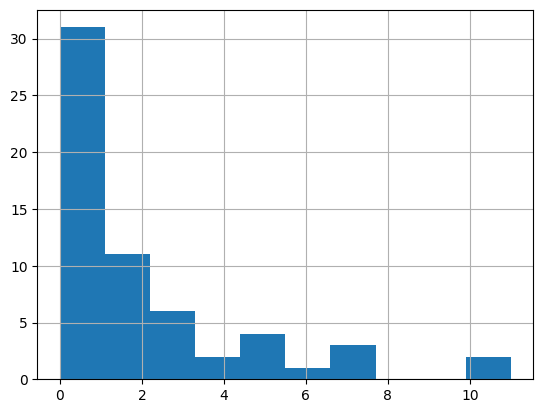

In [20]:
#display distribution of count_3d column
data['count_3d'].hist()

<Axes: >

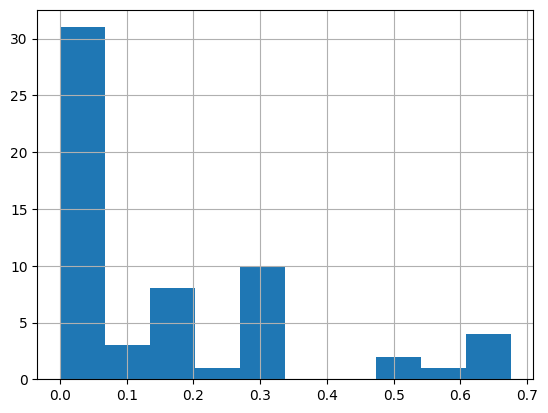

In [21]:
#display histogram of tech_3d dist
data['tech_3d'].hist()

<Axes: >

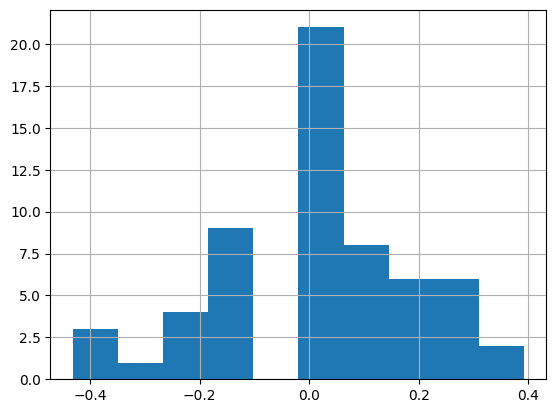

In [22]:
#display histogram of sent_3d.hist
data['sent_3d'].hist()

In [23]:
#log transform count_3d
data['count_3d_log'] = np.log1p(data['count_3d'])
data[['count_3d', 'count_3d_log']].describe().T

,count,mean,std,min,25%,50%,75%,max
count_3d,60.0,2.250000,2.433001,0.0,1.000000,1.000000,3.000000,11.000000
count_3d_log,60.0,0.950421,0.669475,0.0,0.693147,0.693147,1.386294,2.484907


<Axes: >

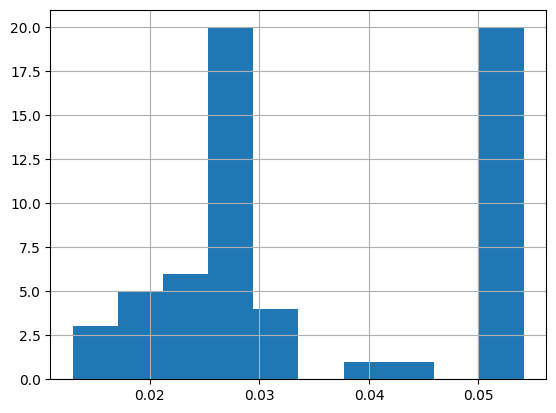

In [24]:
#check dist of var 
data['var'].hist()

I also plotted a time-series plot of the var risk metric and the sentiment feature and tech industry score. The top plot is for the 5% value at risk, which starts low through February and most of March (~1-2%). Around late March 2025, the var goes up to a little less than 3%, and jumps sharply around April 1 to about 5.5%, where is stays through mid-April before falling back towards ~2.5% by mid-May. This lines up with the market uncertainty and event timeline thus far, where China and the US escalated tariffs during the majority of the month of April, and reached a tentative 90 day agreement on May 12. 

The three-day average sentiment plot shows that sentiment is slightly above and below zero in March, with some negative dips. Before the big jump in var, there is a spike to strongly positive sentiment followed by a dip to about -0.4 in mid April. The volatility in sentiment derived by the VADER Sentiment model lines up with the peak in downside risk in the var plot.

The three day average tech-relevance event score from TF-IDF shows that tech-related events in the trade war were around zero in March, but the score shoots up around late March/early April, to around 0.7. This likely reflects the cluster of semiconductor and rare-earth export reports in the timeline. They taper off after mid-April, and the tech score declines back toward zero, just as the var is also declining. 

The event-driven tech tariffs and trade restrictions are captured in a big spike in the tech_3d feature. The sentiment around those days was weirdly positive, to strongly negative (likely because of retaliation), and the combined effect seems to have pushed the market's 5% var higher. The downside risk receded when the tech-specific and negative sentiment events subsided. 

This visual lends confidence to the idea that the combination of sentiment and tech relevance tracks movement in downside risk, which we can potentially quantify in an ML model.

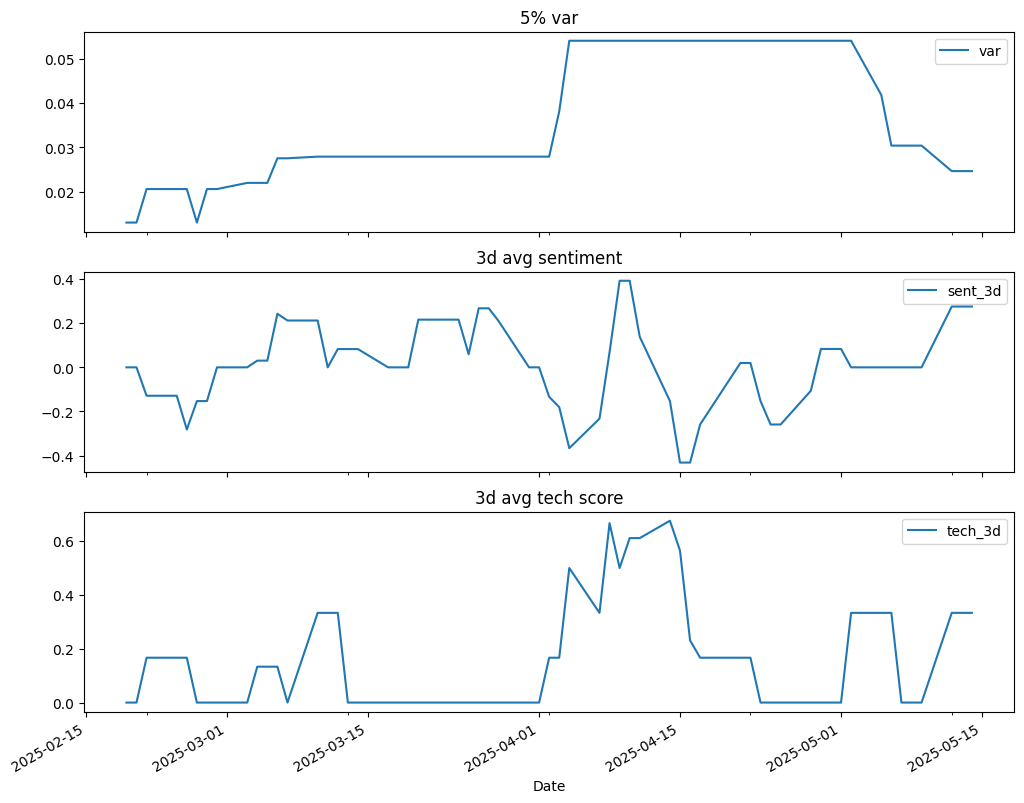

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3,1, figsize=(12,10), sharex=True)
data.plot(x='Date', y='var', ax=ax[0], title='5% var')
data.plot(x='Date', y='sent_3d', ax=ax[1], title='3d avg sentiment')
data.plot(x='Date', y='tech_3d', ax=ax[2], title='3d avg tech score')
plt.show()

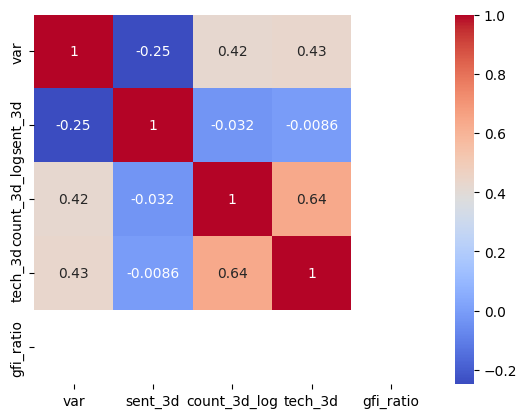

In [26]:
#check correlation matrix
import seaborn as sns

corr = data[['var', 'sent_3d', 'count_3d_log', 'tech_3d', 'gfi_ratio']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

The correlation matrix shows the following:
- var and sent_3d: This has a Pearson score of -0.25, showing that more positive sentiment leads to slightly lower downside risk. This intuitively makes sense.
- var and count_3d_log: This has a score of 0.42, which is moderately positive. This implies that days with more events tend to have higher var.
- var and tech_3d: this is 0.43, also moderately positive. This shows that days with more tech-centered trade policies line up with higher value at risk in the NDX 100. It makes sense that there would be greater potential for financial losses if there is more tech centered trade policies in the trade war.
- sent_3d and count_3d_log: This is close to 0 (0.03) which means that sentiment strength is pretty much independent of how many events occur. This makes sense, given that it is the nature of those events that determine sentiment.
- sent_3d and tech_3d: This is -0.01, which is also close to 0, showing that the sentiment isn't simply driven by the relationship of an event to the technology sector.
- count_3d_log and tech_3d: This has a score of 0.64, which implies that where there are clusters of more events, they tend to have an impact on the tech industry. This also shows mild collinearity, which could interfere with a parametric model but would probably be fine for a Random Forest model or a gradient boosted model.

In [27]:
#check choice of 3 day window 

for lag in [0,1,2,3]:
    r = data['var'].corr(data['sent_3d'].shift(lag))
    print(f"lag {lag} days is corr(var, sent_3d) = {r:.2f}")

lag 0 days is corr(var, sent_3d) = -0.25
lag 1 days is corr(var, sent_3d) = -0.26
lag 2 days is corr(var, sent_3d) = -0.28
lag 3 days is corr(var, sent_3d) = -0.28


The absolute correlation peaks at a lag of two days and is the same at 3 days, so I am sound in my choice of picking a 1 to 3 days window for the value at risk window. 

# Prototype Model

For this task, which is predicting a 5% rolling value at risk on the Nasdaq-100 from text-derived signals, I am considering a Random Forest or Gradient Boosting Regressor. The Random Forest relies on bootstrap sampling and averages the predictions of the samples, which could be good for the spikes in event counts and tech scores and the target variable 'var', which has discrete jumps. Gradient Boosting builds the trees sequentially and corrects previous iterations of the ensemble, and is better for small datasets (we only have 60 rows/events). 

Recall the hypothesis: does negative, tech-focused trade policy in the U.S.-China trade war drive higher downside risk? The hypothesis is looking for a causal link between sentiment/tech focus and downside risk. This requires supervised learning as an approach, because var is modeled as the outcome, and we can quantify feature importances and get interpretable effect sizes such as how a one unit decrease in sentiment drives up value at risk. An unsupervised method could produce a risk index by using the four features of tech_3d, sent_3d, count_3d_log, and gfi_ratio and aggregating them into a single score, but that misses the bulk of why I did the NLP, which is to see how much each NLP feature predicts the market's downside risk. 

I plan to test both models and assess their performance. 

In [28]:
# Re-define your feature list
features = ['sent_3d', 'count_3d_log', 'tech_3d', 'gfi_ratio']

# Diagnostic checks
print("Columns:", data.columns.tolist())
print("\n`var` description:\n", data['var'].describe())
print("Unique `var` values:", data['var'].nunique())
print("\nNaNs in `var` & features:\n", data[['var'] + features].isna().sum())

Columns: ['Date', 'Return', 'var_5pct', 'var', 'sent_3d', 'count_3d', 'tech_3d', 'gfi_ratio', 'count_3d_log']

`var` description:
 count    60.000000
mean      0.035396
std       0.014146
min       0.012986
25%       0.027539
50%       0.027914
75%       0.054148
max       0.054148
Name: var, dtype: float64
Unique `var` values: 10

NaNs in `var` & features:
 var             0
sent_3d         0
count_3d_log    0
tech_3d         0
gfi_ratio       0
dtype: int64


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate #avoid look-ahead bias
from sklearn.metrics import make_scorer, mean_squared_error, r2_score #regression so we use mse and r2

#prepare X, y
features = ['sent_3d', 'count_3d_log', 'tech_3d', 'gfi_ratio'] #pick features
X = data[features].copy()
y = data['var'].copy() #target variable

dates = data['Date'].copy() #for time series CV to make sure we don't have artificially inflated results

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=2025)
tscv = TimeSeriesSplit(n_splits=5) #use default
scoring = {'MSE': make_scorer(mean_squared_error, greater_is_better=False), #MSE is lower is better metric, minimize it
           'R2': make_scorer(r2_score)}

#run time series cross validation
#cross_validate already does our test train split with tscv
cv_results_rf = cross_validate(rf_model, X, y, cv=tscv, scoring=scoring, 
                            return_estimator=True, #to get ft impts
                            n_jobs=1)

mse_scores_rf = -cv_results_rf['test_MSE'] #negative MSE
r2_scores_rf = cv_results_rf['test_R2']

print("RF fold MSE:", mse_scores_rf)
print("RF fold R2:", r2_scores_rf)
print("RF avg cv mse", mse_scores_rf.mean())
print("RF avg cv r2", r2_scores_rf.mean())

RF fold MSE: [6.41797610e-05 1.48048371e-05 7.45967936e-04 8.47479413e-04
 8.91583491e-05]
RF fold R2: [-19.61376302   0.          -8.7375211    0.           0.24772016]
RF avg cv mse 0.0003523180592482111
RF avg cv r2 -5.62071279369632


In [30]:
cv_results_rf

{'fit_time': array([0.02964592, 0.02954316, 0.03071904, 0.02985382, 0.02973008]),
 'score_time': array([0.00279307, 0.00289011, 0.00264788, 0.00264287, 0.00257206]),
 'estimator': [RandomForestRegressor(max_depth=5, random_state=2025),
  RandomForestRegressor(max_depth=5, random_state=2025),
  RandomForestRegressor(max_depth=5, random_state=2025),
  RandomForestRegressor(max_depth=5, random_state=2025),
  RandomForestRegressor(max_depth=5, random_state=2025)],
 'test_MSE': array([-6.41797610e-05, -1.48048371e-05, -7.45967936e-04, -8.47479413e-04,
        -8.91583491e-05]),
 'test_R2': array([-19.61376302,   0.        ,  -8.7375211 ,   0.        ,
          0.24772016])}

In [31]:
#aggregate feature importances (vectorized)
feat_imps = np.vstack([est.feature_importances_ for est in cv_results_rf['estimator']])
mean_imps = feat_imps.mean(axis=0)

importances_df = (
    pd.DataFrame({'feature': features, 'importance':mean_imps})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True))
importances_df

,feature,importance
0,sent_3d,0.496482
1,tech_3d,0.323423
2,count_3d_log,0.180095
3,gfi_ratio,0.000000


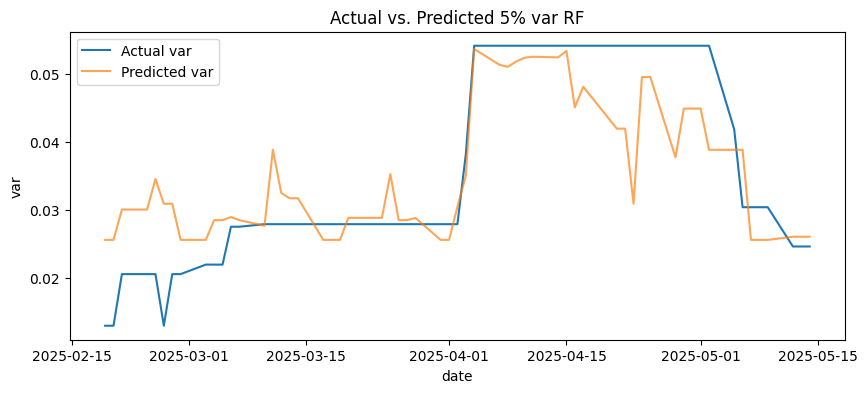

In [37]:
#full-sample prediction

rf_model.fit(X,y)
y_pred = rf_model.predict(X)

plt.figure(figsize=(10,4))
plt.plot(dates, y, label='Actual var')
plt.plot(dates, y_pred, label='Predicted var', alpha=0.7)
plt.title("Actual vs. Predicted 5% var RF")
plt.xlabel('date')
plt.ylabel('var')
plt.legend()
plt.show()

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

#define model, use default hyperparameters
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=2025)

scoring_gb = {'neg_MSE': 'neg_mean_squared_error', 'R2': 'r2'}

#cross-validate 
cv_gb = cross_validate(gb_model, X, y, cv=tscv, scoring=scoring_gb, return_estimator=True, n_jobs=-1)

#summarize cv performance
mse_scores_gb = -cv_gb['test_neg_MSE']
r2_scores_gb = cv_gb['test_R2']

print("GB fold MSE:", mse_scores_gb)
print("GB fold R2:", r2_scores_gb)
print("GB avg cv mse", mse_scores_gb.mean())
print("GB avg cv r2", r2_scores_gb.mean())

GB fold MSE: [6.96312225e-05 1.55960358e-05 7.37588743e-04 1.05048896e-03
 9.60159497e-05]
GB fold R2: [-21.36470651   0.          -8.62814297   0.           0.18985867]
GB avg cv mse 0.00039386418214813355
GB avg cv r2 -5.960598162580522


In [34]:
#aggregate feature importances (vectorized)
feat_imps_gb = np.vstack([est.feature_importances_ for est in cv_gb['estimator']])
mean_imps_gb = feat_imps_gb.mean(axis=0)

importances_df_gb = (
    pd.DataFrame({'feature': features, 'importance':mean_imps_gb})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True))
importances_df_gb

,feature,importance
0,sent_3d,0.478599
1,tech_3d,0.431187
2,count_3d_log,0.090214
3,gfi_ratio,0.000000


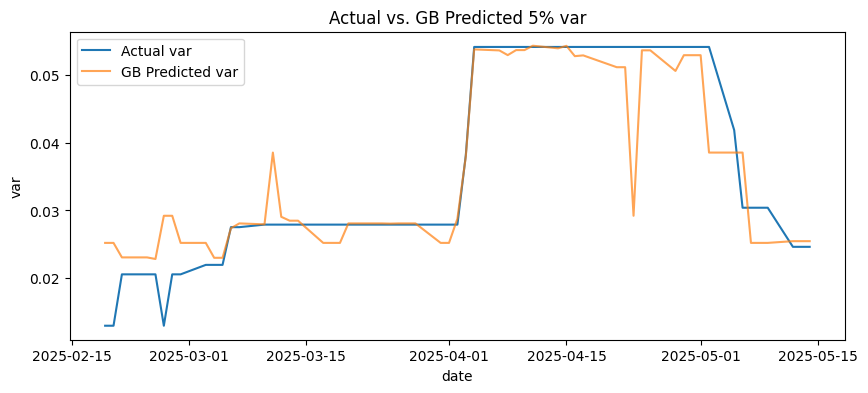

In [35]:
#fit and predict for GB model
gb_model.fit(X,y)
y_pred_gb = gb_model.predict(X)

plt.figure(figsize=(10,4))
plt.plot(dates, y, label='Actual var')
plt.plot(dates, y_pred_gb, label='GB Predicted var', alpha=0.7)
plt.title("Actual vs. GB Predicted 5% var")
plt.xlabel('date')
plt.ylabel('var')
plt.legend()
plt.show()

In [36]:
#compare metrics side by side 
compare = pd.DataFrame({'GB Avg MSE': mse_scores_gb.mean(), 'RF Avg MSE': mse_scores_rf.mean(),
                        'GB Avg R2': r2_scores_gb.mean(), 'RF Avg R2': r2_scores_rf.mean()}, index=[0])
compare

,GB Avg MSE,RF Avg MSE,GB Avg R2,RF Avg R2
0,0.000394,0.000352,-5.960598,-5.620713


# Comparing Model Performance

## Cross Validation Metrics
The ${R^2}_{GB}$ = -5.96 and the ${R^2}_{RF}$ = -5.62. These are really high values for the $R^2$ score. On average, the Gradient Boosting model's squared errors are 5.96 times larger than the total variance of the 'var' target variable, and the RF model's squared errors are 5.62 times larger than the total variance of the 'var' target variable. This means that the model is doing much worse than just predicting the mean value at risk every day. The Random Forest has a smaller MSE and a smaller ${R^2}$, but the GB model explains more of the day-to-day variance of the var than the RF model.

The large $R^2$ values could indicate a few things stemming from the data that are causing this outcome. The target variable of 'var' is very noisy. I rolled the 5% value at risk on a 21 day window initially, and this means that it can jump around a lot and make it hard to predict just from three-day sentiment and event features we derived from the NLP. I also might have insufficient features. There are four predictors, one of which is constant for China and for the US (the global firepower index value) and three NLP derived features from a relatively small dataset (only 61 rows). These aren't sufficient predictors for a target variable that is probably driven by lots of other market forces (employment, earnings, trade flows, and Fed policy, among other things). 

The small dataset also means the model could be overfitting to patterns and isn't generalizing properly. 

## Comparing the Plots
The plots for the GB and RF models basically capture the same broad trends, such as low var in February through March, a sharp jump in early April, and a decline in early May. Notably, both models predict more variation between early April and early May, while the actual var plateaus during this time. 

The GB predictions are smoother than the RF. The RF model overestimates downside risk in early March and underestimates it during the April-May plateau. The GB tracks the actual var predictions more tightly, especially around the high risk plateau, with some under and over shoots around mid-April. The closer fit is reflected in the higher cross validated $R^2$ score for the GB model. 

Both the RF and GB models perform worse early on in the data, but this is likely due to the sparsity in the original NLP dataset of events that took place prior to April, when the trade war really picked up speed. The large dip both models have during the plateau suggest overfitting to training data. 

The gradient-boosted model seems to align better with realized risk and appears more precise.

## Where does the model over-predict and under-predict?

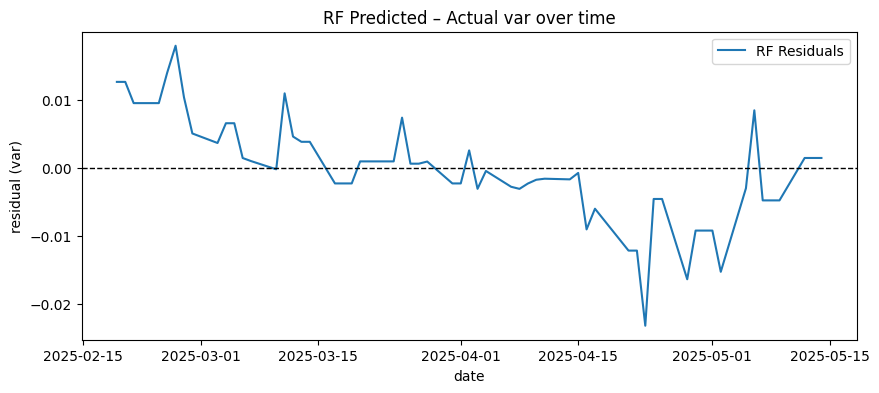

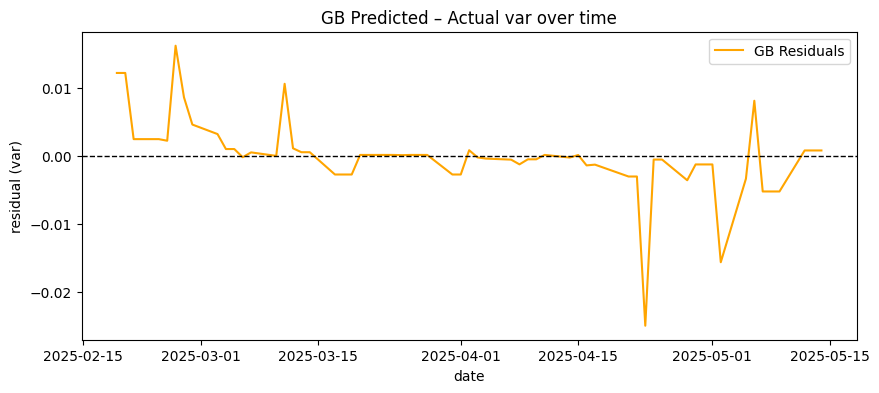

In [40]:
#compute residuals
resid_rf = y_pred - y
resid_gb = y_pred_gb    - y

#plot RF residuals over time
plt.figure(figsize=(10,4))
plt.plot(dates, resid_rf, label='RF Residuals')
plt.axhline(0, color='black', linestyle='--', linewidth=1) #0
plt.title("RF Predicted – Actual var over time")
plt.xlabel("date")
plt.ylabel("residual (var)")
plt.legend()
plt.show()

#plot GB residuals over time
plt.figure(figsize=(10,4))
plt.plot(dates, resid_gb, color='orange', label='GB Residuals')
plt.axhline(0, color='black', linestyle='--', linewidth=1) #0
plt.title("GB Predicted – Actual var over time")
plt.xlabel("date")
plt.ylabel("residual (var)")
plt.legend()
plt.show()

The RF model residuals (in blue) stay between about 0.015 and -0.025. Early in the dataset, the model overpredicts var, as indicated by the positive residuals, and from mid-April on, it consistently underpredicts, as indicated by the negative residuals. The GB model residuals (in orange) are much closer to zero for most of the period, reflecting a tighter overall fit. They also undepredict around April, with a single sharp dip near -0.025. The GB model also corrects faster for the first risk spike around February. The GB model's errors are more systematically distributed around zero, while RF seems to have a bias toward underestimating high risk days. This pattern also aligns with the $R^2$ scores for the models, where the GB model captures the variability in var more precisely. The tradeoff appears to be overreacting to certain events.

## Get the SHAP values

Getting the SHAP values can help us see how much each individual feature contributes to the model's output. A beeswarm plot can show us a global summary of feature importance and direction. Each dot is a SHAP value for one instance-feature pair, and is color coded by the feature value (high to low). 

In [43]:
!pip install shap --quiet

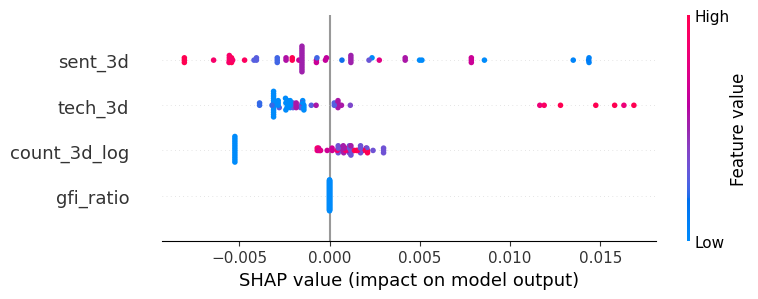

In [55]:
import shap

#create shap explainer for RF model
explainer_rf = shap.TreeExplainer(rf_model)

#calculate SHAP values for feature matrix
shap_values_rf = explainer_rf.shap_values(X)

#plot summary beeswarm of mean abs shap value
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values_rf, X, feature_names=features, show=True)

The SHAP beeswarm plot for the RF model shows negative sentiment (blue points) lying mostly to the right, indicating a positive SHAP value. This means that when sentiment is negative, the model raises its var prediction. The red points are to the left, indicating a negative SHAP value, so more positive sentiment pulls the predicted risk down. 

The red points for tech_3d indicate a high positive SHAP values, showing that tech-focused tariff and trade policy pushes the predicted var up. The blue points clustered negatively/around zero indicate low impact on increasing risk.

The count_3d_log has most values close to zero, but to the right, showing that the three day windows with more events tend to increase the risk forecast, but only slightly. The blue dots to the left are negative but close to zero, so days with few to no trade events have little impact on var.

The gfi_ratio is at zero, which means that US-China power ratio has little impact on var in this window. 

Overall, the count_3d_log feature (the log-transformed count of trade events) and tech industry impacting events (tech_3d) have the largest impact on the predicted downside risk. Sentiment has a directionally opposite effect, and gfi_ratio has little impact on the model.

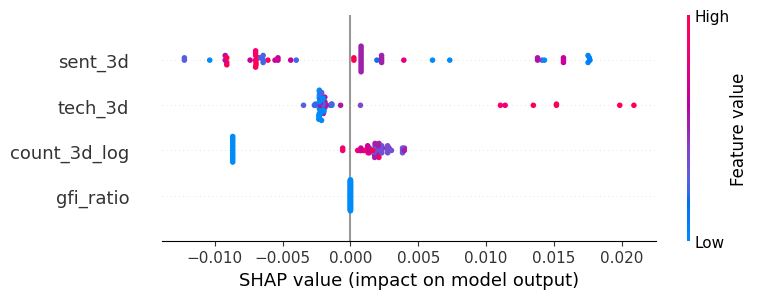

In [56]:
#create shap explainer for GB model
explainer_gb = shap.TreeExplainer(gb_model)

#calculate SHAP values for feature matrix
shap_values_gb = explainer_gb.shap_values(X)

#plot summary beeswarm of mean abs shap value
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values_gb, X, feature_names=features, show=True)

The beeswarm plot for the GB model shows the blue points for sent_3d as lying mostly to the right of zero, meaning negative sentiment increases risk forecasts by the model. The red points, showing positive sentiment, tend to cluster to the left of zero, so it shows that higher sentiment reduces downside risk. The low tech_3d SHAP values cluster mostly around zero, showing days with no high technology score have less impact on downside risk. The red dots are much further to the right of zero, indicating that days with semiconductor/technology events lead the model to raise its var estimate. The count_3d_log shows that days with more events push the risk prediction higher (red dots are positive and high), while days with less events push the risk low. The gfi_ratio is again, consistently zero, showing no influence on the model's prediction of var.

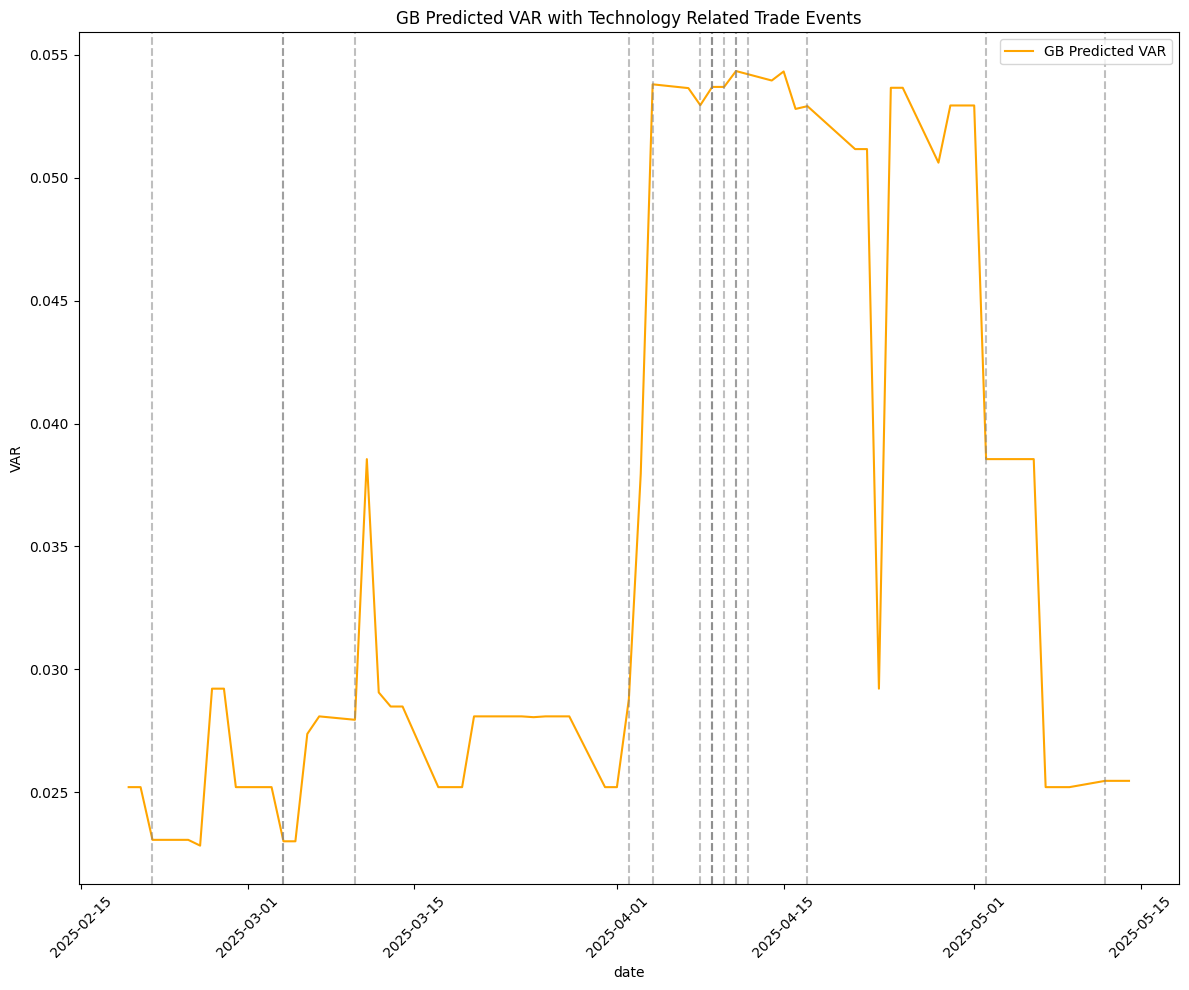

In [76]:
#plot index
#filter the events just for tech
filters = ((timeline['Date'] >= data['Date'].min()) &
           (timeline['Date'] <= data['Date'].max()) &
           (timeline['tech_score_tf_idf'] == 1)) # plotting the event lines only for tech related

tech_events = timeline.loc[filters, ['Date', 'Description']]

#get series of gb preds indexed by date
gb_series = pd.Series(y_pred_gb, index=data['Date'])

#plot gb pred var
fig, ax = plt.subplots(figsize=(12,10))
ax.plot(data['Date'], y_pred_gb, color='orange', label='GB Predicted VAR')

#annotate only tech industry related events
for _, row in tech_events.iterrows():
    date = row['Date']
    # get the predicted var on that date
    y_val = gb_series.get(date, np.nan)
    ax.axvline(date, color='grey', linestyle='--', alpha=0.5)

ax.set_title("GB Predicted VAR with Technology Related Trade Events")
ax.set_xlabel("date")
ax.set_ylabel("VAR")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
data.to_csv('data.csv', index=False)

In [ ]:
#not super useful for predicting because the nlp data is super erratic, 